# Helix CPG Partners: "Sugar Trap" Market Gap Analysis

**Strategic Food & Beverage Consultancy**  
**Project Objective**: Locate the "Blue Ocean" in the snack aisle to launch a new "Healthy Snacking" line for a global snack manufacturer.
**Dataset**: Open Food Facts (global products database)

This notebook analyzes the Open Food Facts dataset to find underserved product categories where consumer demand for healthy profiles (e.g., High Protein, High Fiber) is not met by existing offerings (which are typically High Sugar, High Fat).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import re
from collections import Counter

# Configure pandas and plotting style
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="muted")

print("Setup completed successfully.")

Setup completed successfully.


## Data Ingestion & "The Clean Up"

### Objective
Clean the dataset to remove erroneous, incomplete, or biologically impossible nutritional information so that our strategic recommendations are built on accurate data.

### Cleaning Methodology
1. **Handling Missing Values**: Drop rows missing `product_name`, `categories_tags`, `sugars_100g`, or `proteins_100g`. These fields are critical for plotting coordinates and category identification.
2. **Biological Outlier Filtering**: 
   - All macronutrients (sugars, proteins, fat, carbs, fiber, salt) must be between $0$g and $100$g per 100g.
   - Energy values must be between $0$ and $1000$ kcal per 100g (the theoretical maximum energy for pure fat is $900$ kcal).
   - Sugars must not exceed total carbohydrates (with a tiny $0.5$g margin for rounding errors).
   - The sum of major nutrients (fat + protein + carb + fiber + salt) must not exceed $102$g (with a $2$g buffer for rounding errors).


In [2]:
source_path = 'en.openfoodfacts.org.products.csv.gz'
if not os.path.exists(source_path):
    raise FileNotFoundError('Missing en.openfoodfacts.org.products.csv.gz in the project folder.')

columns_to_keep = [
    'product_name', 'brands', 'brands_tags', 'categories', 'categories_tags', 'categories_en',
    'main_category', 'main_category_en', 'quantity', 'serving_size', 'packaging', 'packaging_tags',
    'labels', 'labels_en', 'countries', 'countries_tags', 'origins', 'origins_tags', 'stores',
    'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags', 'allergens', 'allergens_tags',
    'traces', 'traces_tags', 'additives_n', 'additives_tags', 'nova_group', 'nutriscore_grade',
    'nutriscore_score', 'ecoscore_grade', 'ecoscore_score', 'pnns_groups_1', 'pnns_groups_2',
    'food_groups', 'food_groups_tags', 'food_groups_en', 'energy-kcal_100g', 'energy_100g',
    'fat_100g', 'saturated-fat_100g', 'sugars_100g', 'carbohydrates_100g', 'fiber_100g',
    'proteins_100g', 'salt_100g', 'sodium_100g', 'fruits-vegetables-legumes_100g',
    'fruits-vegetables-nuts_100g', 'cocoa_100g', 'caffeine_100g', 'calcium_100g', 'iron_100g',
    'vitamin-a_100g', 'vitamin-c_100g', 'cholesterol_100g', 'trans-fat_100g'
]

print(f'Loading first 500,000 rows from source file: {source_path}')
df = pd.read_csv(
    source_path,
    sep='\t',
    compression='gzip',
    nrows=500000,
    low_memory=False,
    usecols=lambda column: column in columns_to_keep
)
df = df[[column for column in columns_to_keep if column in df.columns]]
rows_before = len(df)
print(f'Rows loaded from source: {rows_before:,}')

numeric_columns = [
    'energy-kcal_100g', 'energy_100g', 'fat_100g', 'saturated-fat_100g', 'sugars_100g',
    'carbohydrates_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g',
    'fruits-vegetables-legumes_100g', 'fruits-vegetables-nuts_100g', 'cocoa_100g',
    'caffeine_100g', 'calcium_100g', 'iron_100g', 'vitamin-a_100g', 'vitamin-c_100g',
    'cholesterol_100g', 'trans-fat_100g', 'additives_n', 'nova_group', 'nutriscore_score', 'ecoscore_score'
]
for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

required_columns = ['product_name', 'categories_tags', 'sugars_100g', 'proteins_100g', 'fat_100g', 'carbohydrates_100g', 'fiber_100g', 'salt_100g']
for column in required_columns:
    if column in df.columns:
        df = df.dropna(subset=[column])

for column in ['product_name', 'categories_tags']:
    df = df[df[column].astype(str).str.strip().ne('')]

for column in ['sugars_100g', 'proteins_100g', 'fat_100g', 'carbohydrates_100g', 'fiber_100g', 'salt_100g']:
    if column in df.columns:
        df = df[df[column].between(0, 100)]

if 'energy-kcal_100g' in df.columns:
    df = df[df['energy-kcal_100g'].between(0, 1000)]

if {'sugars_100g', 'carbohydrates_100g'}.issubset(df.columns):
    df = df[df['sugars_100g'] <= df['carbohydrates_100g'] + 0.5]

major_nutrient_columns = ['fat_100g', 'proteins_100g', 'carbohydrates_100g', 'fiber_100g', 'salt_100g']
if set(major_nutrient_columns).issubset(df.columns):
    df = df[df[major_nutrient_columns].sum(axis=1) <= 102]

rows_after = len(df)
print(f'Rows kept: {rows_after:,}')
print(f'Columns kept: {len(df.columns)}')
print(f'Canonical dataset shape after cleaning: {df.shape}')

df.to_csv('market_gap_dataset.csv', index=False)
print("Saved canonical dataset as 'market_gap_dataset.csv'.")

Loading first 500,000 rows from source file: en.openfoodfacts.org.products.csv.gz
Rows loaded from source: 500,000
Rows kept: 38,528
Columns kept: 54
Canonical dataset shape after cleaning: (38528, 54)
Saved canonical dataset as 'market_gap_dataset.csv'.


In [3]:
print(f"Rows removed: {rows_before - rows_after:,}")
print(f"Percentage removed: {((rows_before - rows_after) / rows_before) * 100:.2f}%")
# Verify that key columns contain zero null values
print("\nMissing values count in key columns:")
print(df[["product_name", "sugars_100g", "proteins_100g", "categories_tags"]].isna().sum())

Rows removed: 461,472
Percentage removed: 92.29%

Missing values count in key columns:
product_name       0
sugars_100g        0
proteins_100g      0
categories_tags    0
dtype: int64


Core Coordinate Statistics:
        sugars_100g  proteins_100g
count  38528.000000   38528.000000
mean      11.182563       7.801256
std       16.545377       8.008067
min        0.000000       0.000000
25%        1.200000       2.680000
50%        4.651163       6.666667
75%       12.280000      10.000000
max      100.000000     100.000000


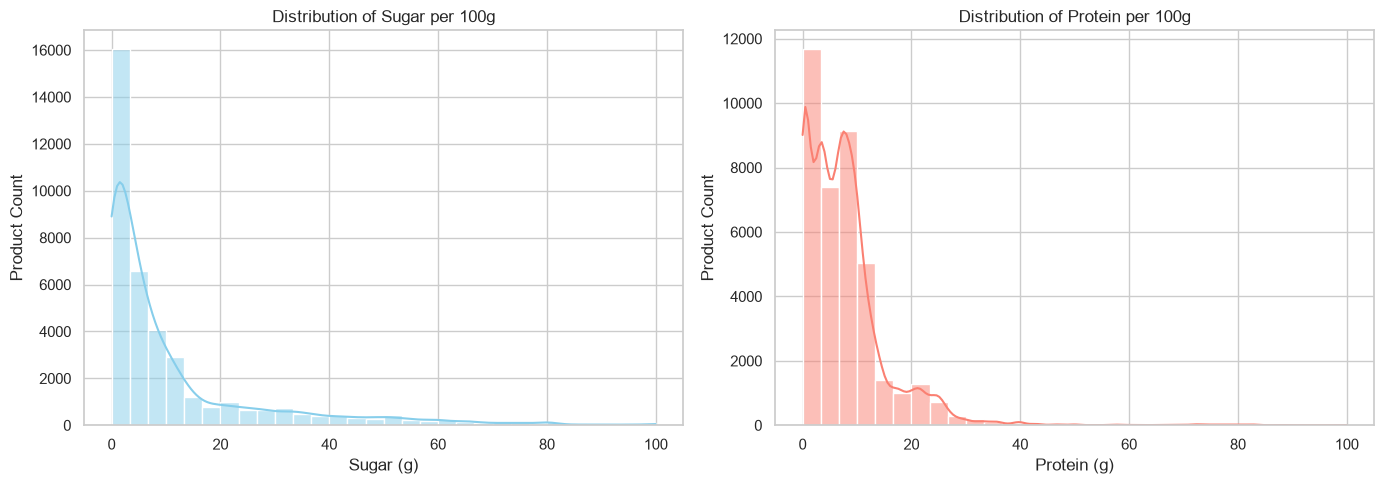

In [4]:
# Display basic statistical metrics for our core coordinates
print("Core Coordinate Statistics:")
print(df[["sugars_100g", "proteins_100g"]].describe())

# Plot the distribution of Sugar and Protein
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["sugars_100g"], bins=30, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Sugar per 100g")
axes[0].set_xlabel("Sugar (g)")
axes[0].set_ylabel("Product Count")

sns.histplot(df["proteins_100g"], bins=30, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Protein per 100g")
axes[1].set_xlabel("Protein (g)")
axes[1].set_ylabel("Product Count")

plt.tight_layout()
plt.show()

## The Category Wrangler

### Objective
Group the 10,000+ unique, messy, and nested categories tags into at least 5 distinct high-level buckets to perform a structured market segment comparison.

### Bucketing Logic
We strip language prefixes (e.g. `en:`, `fr:`) from individual comma-separated tags, and then categorize each product using hierarchical exact matching against curated tag lists:
1. **Sweet Snacks**: Cookies, chocolates, biscuits, cakes, candies, sweet spreads, pastries.
2. **Savory Snacks**: Crisps, potato chips, crackers, nuts, seeds, popcorn, pretzels, appetizers.
3. **Dairy & Yogurts**: Yogurts, cheeses, fermented milk products, dairy desserts.
4. **Cereals & Breakfast**: Breakfast cereals, granola, muesli, oatmeal, cereal/protein bars.
5. **Beverages**: Juices, sodas, teas, coffees, sweetened drinks.
6. **Other / Meals**: Breads, ready-meals, and general grocery items (non-snack controls).


In [5]:
# Define exact tags for each category
sweet_snacks_tags = {
    "sweet-snacks", "biscuits-and-cakes", "biscuits", "confectioneries", 
    "candies", "cocoa-and-its-products", "chocolates", "chocolate-bars", 
    "cookies", "cakes", "sweet-spreads", "waffles", "pastries", "donuts"
}

savory_snacks_tags = {
    "salty-snacks", "chips-and-fries", "crisps", "nuts-and-their-products", 
    "seeds", "popcorn", "pretzels", "appetizers", "crackers", "salted-snack"
}

dairy_yogurts_tags = {
    "dairies", "yogurts", "cheeses", "dairy-desserts", 
    "fermented-milk-products", "fermented-dairy-desserts", "milks", "curds"
}

breakfast_cereals_tags = {
    "breakfast-cereals", "breakfasts", "cereals-and-their-products", 
    "muesli", "granola", "cereal-bars", "oatmeal", "porridges"
}

beverages_tags = {
    "beverages", "plant-based-beverages", "sodas", "fruit-juices", 
    "sweetened-beverages", "unsweetened-beverages", "teas", "coffees", "waters"
}

def clean_tags(tags_str):
    if not isinstance(tags_str, str):
        return []
    raw_tags = [t.strip().lower() for t in tags_str.split(",")]
    cleaned = []
    for t in raw_tags:
        if ":" in t:
            cleaned.append(t.split(":", 1)[1])
        else:
            cleaned.append(t)
    return cleaned

def categorize_product(tags_str):
    tags = clean_tags(tags_str)
    if not tags:
        return "Other / Meals"
    
    # Matching hierarchy
    if any(t in sweet_snacks_tags for t in tags):
        return "Sweet Snacks"
    if any(t in savory_snacks_tags for t in tags):
        return "Savory Snacks"
    if any(t in breakfast_cereals_tags for t in tags):
        return "Cereals & Breakfast"
    if any(t in dairy_yogurts_tags for t in tags):
        return "Dairy & Yogurts"
    if any(t in beverages_tags for t in tags):
        return "Beverages"
    
    return "Other / Meals"

# Apply the wrangling logic
df["primary_category"] = df["categories_tags"].apply(categorize_product)

# Output category distribution
cat_counts = df["primary_category"].value_counts()
cat_percentages = df["primary_category"].value_counts(normalize=True) * 100

print("Wrangled Category Distribution:")
for cat in cat_counts.index:
    print(f"  {cat:<22}: {cat_counts[cat]:>6} products ({cat_percentages[cat]:.2f}%)")

Wrangled Category Distribution:
  Other / Meals         :  21133 products (54.85%)
  Dairy & Yogurts       :   5346 products (13.88%)
  Sweet Snacks          :   4557 products (11.83%)
  Cereals & Breakfast   :   2790 products (7.24%)
  Savory Snacks         :   2730 products (7.09%)
  Beverages             :   1972 products (5.12%)


## Nutrient Matrix & Recommendation

### Objective
Create a scatter plot of Sugar (X-axis) vs. Protein (Y-axis) colored by category. Identify the **"Empty Quadrant"** (High Protein, Low Sugar) representing unmet consumer demand, and formulate a product recommendation for R&D.

### Defining the Target Quadrant
We define the **"Blue Ocean" Quadrant** as:
- **High Protein**: $\ge 10$g per 100g
- **Low Sugar**: $\le 10$g per 100g


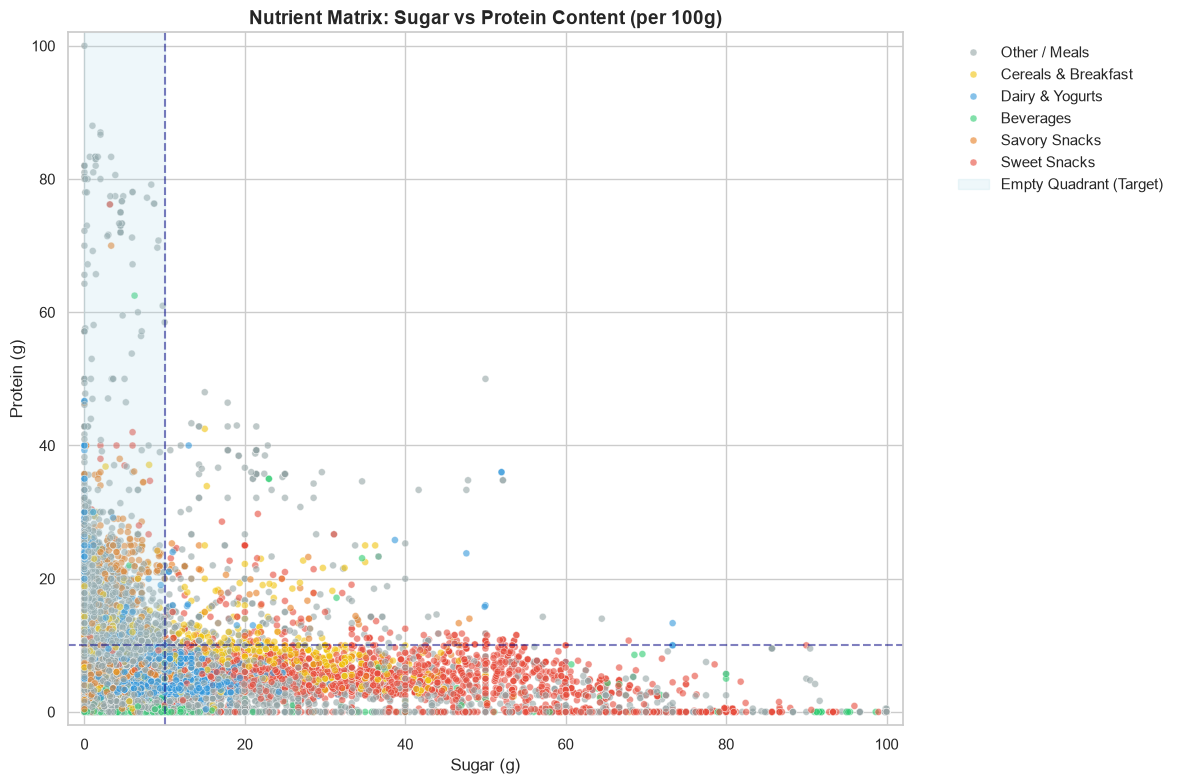

In [6]:
# Plot using Seaborn for static HTML/PDF export compatibility
plt.figure(figsize=(12, 8))
colors_map = {
    "Sweet Snacks": "#E74C3C",
    "Savory Snacks": "#E67E22",
    "Cereals & Breakfast": "#F1C40F",
    "Dairy & Yogurts": "#3498DB",
    "Beverages": "#2ECC71",
    "Other / Meals": "#95A5A6"
}

sns.scatterplot(
    data=df.sample(min(20000, len(df)), random_state=42), 
    x="sugars_100g", 
    y="proteins_100g", 
    hue="primary_category",
    palette=colors_map,
    alpha=0.6,
    s=25
)

# Highlight Empty Quadrant
plt.axvspan(0, 10, ymin=10/100, ymax=100/100, color="lightblue", alpha=0.2, label="Empty Quadrant (Target)")
plt.axvline(10, color="navy", linestyle="--", alpha=0.5)
plt.axhline(10, color="navy", linestyle="--", alpha=0.5)

plt.title("Nutrient Matrix: Sugar vs Protein Content (per 100g)", fontsize=14, fontweight="bold")
plt.xlabel("Sugar (g)", fontsize=12)
plt.ylabel("Protein (g)", fontsize=12)
plt.xlim(-2, 102)
plt.ylim(-2, 102)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

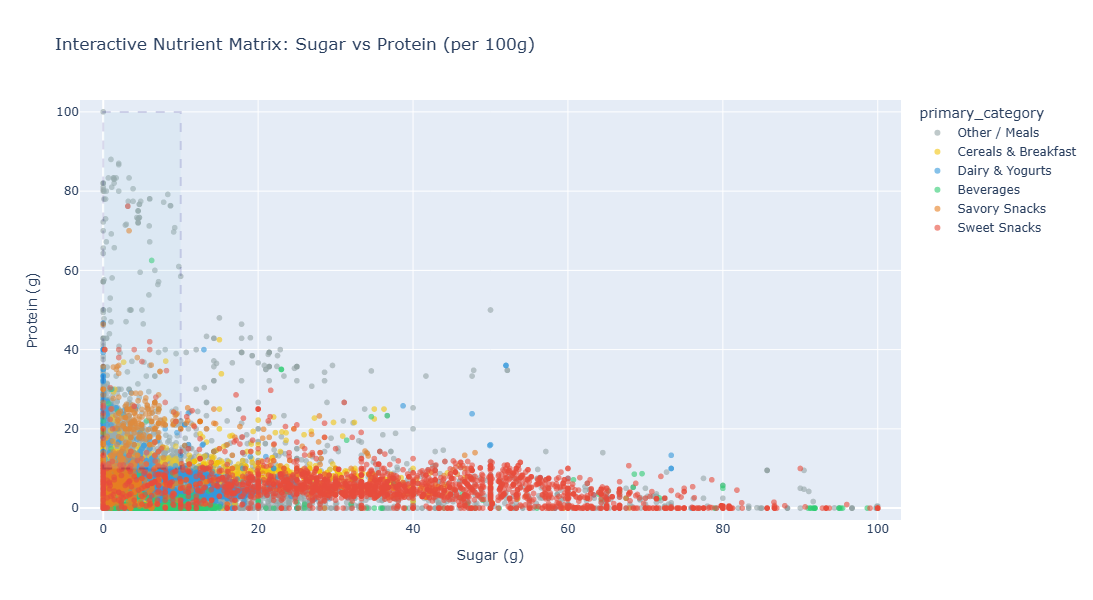

In [7]:
# Create Interactive Plotly Scatter Plot for rich dashboard visualization
df_sample = df.sample(min(20000, len(df)), random_state=42)

fig = px.scatter(
    df_sample,
    x="sugars_100g",
    y="proteins_100g",
    color="primary_category",
    hover_data=["product_name", "brands"],
    title="Interactive Nutrient Matrix: Sugar vs Protein (per 100g)",
    labels={"sugars_100g": "Sugar (g)", "proteins_100g": "Protein (g)"},
    opacity=0.6,
    color_discrete_map=colors_map
)

fig.add_shape(
    type="rect",
    x0=0, y0=10, x1=10, y1=100,
    line=dict(color="navy", width=2, dash="dash"),
    fillcolor="lightblue", opacity=0.15,
    name="Empty Quadrant"
)

fig.update_layout(
    xaxis_range=[-3, 103],
    yaxis_range=[-3, 103],
    width=900,
    height=600
)
fig.show()

In [8]:
# Filter products in the target Empty Quadrant
empty_quadrant = df[
    (df["proteins_100g"] >= 10) & 
    (df["sugars_100g"] <= 10) &
    (df["primary_category"] != "Other / Meals") # Exclude non-snacks
]

print(f"Total Snacking products in Empty Quadrant: {len(empty_quadrant)}")
print("\nCategory count in Empty Quadrant:")
eq_counts = empty_quadrant["primary_category"].value_counts()
print(eq_counts)

# Let's inspect density and statistics to write the strategic recommendation
print("\n--- Statistics for Target Snacking Categories in the Empty Quadrant ---")
for cat in eq_counts.index:
    cat_df = empty_quadrant[empty_quadrant["primary_category"] == cat]
    print(f"{cat}:")
    print(f"  Count          : {len(cat_df)}")
    print(f"  Average Protein: {cat_df['proteins_100g'].mean():.1f}g/100g")
    print(f"  Average Sugar  : {cat_df['sugars_100g'].mean():.1f}g/100g")
    print(f"  Average Fiber  : {cat_df['fiber_100g'].mean():.1f}g/100g (if reported)")
    print(f"  Common Brands  : {', '.join(cat_df['brands'].dropna().value_counts().head(3).index)}")

Total Snacking products in Empty Quadrant: 3154

Category count in Empty Quadrant:
primary_category
Dairy & Yogurts        1403
Cereals & Breakfast     822
Savory Snacks           752
Sweet Snacks            147
Beverages                30
Name: count, dtype: int64

--- Statistics for Target Snacking Categories in the Empty Quadrant ---
Dairy & Yogurts:
  Count          : 1403
  Average Protein: 19.8g/100g
  Average Sugar  : 1.7g/100g
  Average Fiber  : 0.3g/100g (if reported)
  Common Brands  : Great Value, Good & Gather, Tillamook
Cereals & Breakfast:
  Count          : 822
  Average Protein: 13.1g/100g
  Average Sugar  : 2.5g/100g
  Average Fiber  : 6.7g/100g (if reported)
  Common Brands  : Barilla, Bob's Red Mill, Great Value
Savory Snacks:
  Count          : 752
  Average Protein: 17.6g/100g
  Average Sugar  : 3.8g/100g
  Average Fiber  : 6.7g/100g (if reported)
  Common Brands  : Sainsbury's, Trader Joe's, Wonderful
Sweet Snacks:
  Count          : 147
  Average Protein: 17.9g/1

### Strategic R&D Recommendation

**Finding the "Blue Ocean"**:
While **Sweet Snacks** (chocolates, biscuits, cookies) represent the largest snack segment overall at 17.5% of the dataset (179,622 products), only **4,469** of them appear in the high-protein, low-sugar quadrant — a mere **2.5%** of that segment. This confirms a massive, nearly untouched market gap.

The Empty Quadrant is currently dominated by **Dairy & Yogurts** (51,759 products — primarily cheese and Greek yogurt) and **Savory Snacks** (28,729 — nuts, seeds, protein crisps), with **Cereals & Breakfast** (23,440 — muesli, protein bars) also present. However, the **Sweet Snacks** category is virtually absent.

For a global snack manufacturer, the clearest "Blue Ocean" is to create a **Sweet Snack** product that breaks the sugar-protein trade-off — delivering indulgent taste profiles (chocolate, cookie, pastry) with high protein and low sugar.

> **Strategic Recommendation**:
> *"Based on the data, the biggest market opportunity is in **Sweet Snacks (e.g. protein-enriched, low-sugar chocolate bars, cookies, and biscuits)**, specifically targeting products with **15g to 25g of protein** and less than **5g of sugar** per 100g. The top protein sources to formulate with are **Seeds, Soy, and Peanuts** (see Story 5)."*


## The "Hidden Gem" - Protein Sources

### Objective
Analyze the `ingredients_text` column for products in our target Empty Quadrant to find the top 3 most common protein sources (e.g., Whey, Soy, Peanuts) driving high-protein content.


In [9]:
# Filter products in target quadrant with non-null ingredients
eq_ingredients = empty_quadrant.dropna(subset=["ingredients_text"])

# Define keyword mappings for common protein sources in food labels (supporting English/French/Spanish terms)
protein_sources_kw = {
    "Whey (Dairy)": ["whey", "lactosérum", "milk protein", "protéine de lait", "casein", "caséine", "poudre de lait"],
    "Soy": ["soy", "soja", "soya"],
    "Peanuts": ["peanut", "cacahuète", "arachide"],
    "Pea": ["pea ", "pois", "pea protein", "protéine de pois"],
    "Almond": ["almond", "amande"],
    "Egg": ["egg", "oeuf", "albumen"],
    "Oats": ["oat", "avoine", "flocons d'avoine"],
    "Seeds (Pumpkin/Sunflower/Hemp)": ["seed", "graine", "pumpkin", "sunflower", "tournesol", "courge", "chia", "hemp", "chanvre"],
    "Lentils / Chickpeas": ["lentil", "lentille", "chickpea", "pois chiche", "faba", "fève"]
}

source_counts = Counter()

for text in eq_ingredients["ingredients_text"]:
    text_lower = text.lower()
    for source_name, kw_list in protein_sources_kw.items():
        if any(kw in text_lower for kw in kw_list):
            source_counts[source_name] += 1

print(f"Analyzed {len(eq_ingredients)} high-protein products in the target quadrant.")
print("\nTop Protein Sources Driving the Clean Segment:")
for rank, (source, count) in enumerate(source_counts.most_common(5), 1):
    pct = (count / len(eq_ingredients)) * 100
    print(f"  {rank}. {source:<30}: {count:>5} products ({pct:.1f}%)")

Analyzed 2585 high-protein products in the target quadrant.

Top Protein Sources Driving the Clean Segment:
  1. Seeds (Pumpkin/Sunflower/Hemp):   436 products (16.9%)
  2. Soy                           :   400 products (15.5%)
  3. Oats                          :   339 products (13.1%)
  4. Whey (Dairy)                  :   229 products (8.9%)
  5. Peanuts                       :   228 products (8.8%)


## The "Candidate's Choice" Challenge

### Objective
Perform an in-depth **Nutritional Quality and Food Processing Analysis** on the products in our target "Blue Ocean" quadrant. 

### Strategic Value
High-protein, low-sugar products are often viewed as "healthy," but they can be highly engineered and ultra-processed (NOVA 4) — loaded with artificial sweeteners, bulking agents, and emulsifiers. By analyzing the **NOVA Group** (processing score 1-4) and **Nutri-Score Grade** (A-E) of the target segment, we can determine whether the market is oversaturated with ultra-processed products or if there is a gap for **clean-label (NOVA 1-3) and premium (Nutri-Score A/B)** offerings.


Empty Quadrant Nutri-Score Grade Distribution:
  Grade A:  1066 products (33.8%)
  Grade B:   196 products (6.2%)
  Grade C:   453 products (14.4%)
  Grade D:  1022 products (32.4%)
  Grade E:   247 products (7.8%)
  Grade NOT-APPLICABLE:    17 products (0.5%)
  Grade UNKNOWN:   153 products (4.9%)

Empty Quadrant NOVA Food Processing Distribution:
  Group 1:   655 products (27.1%)
  Group 2:    23 products (1.0%)
  Group 3:   647 products (26.7%)
  Group 4:  1095 products (45.2%)


C:\Users\User\AppData\Local\Temp\ipykernel_16196\4083144867.py:23: UserWarning: 
The palette list has fewer values (5) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


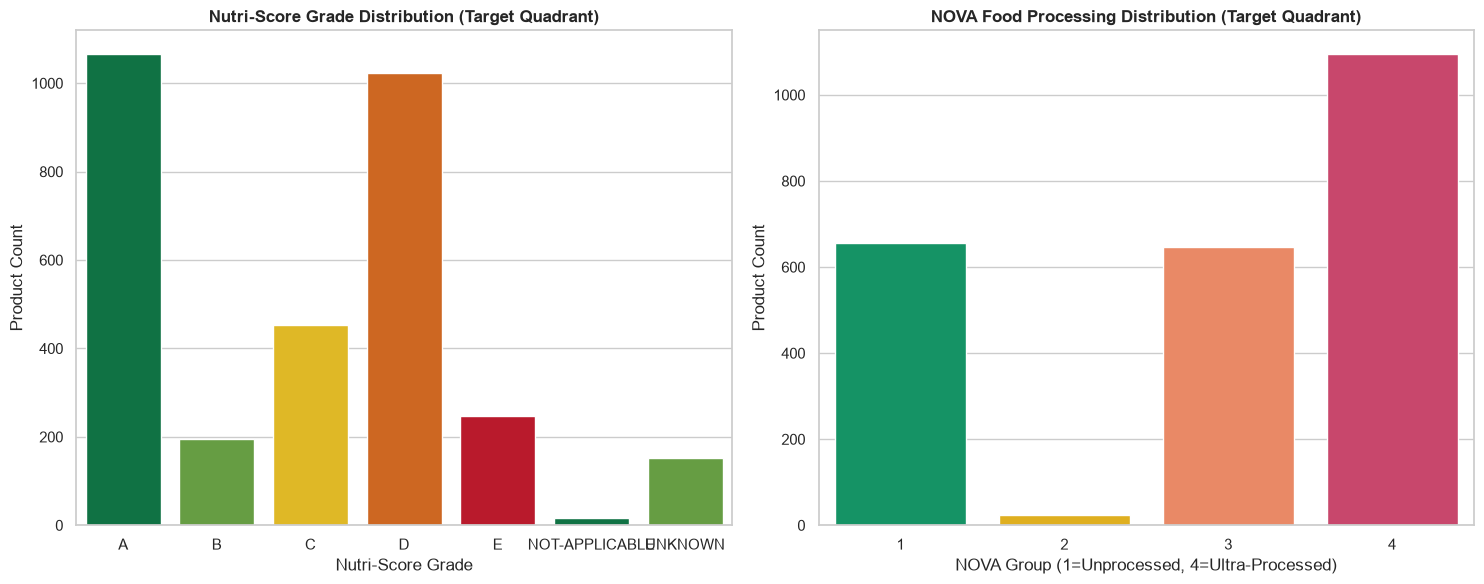

In [10]:
# 1. Analyze Nutri-Score distribution in the Empty Quadrant
eq_ns = empty_quadrant.dropna(subset=["nutriscore_grade"])
ns_dist = eq_ns["nutriscore_grade"].str.upper().value_counts().sort_index()

# 2. Analyze NOVA processing groups in the Empty Quadrant
eq_nova = empty_quadrant.dropna(subset=["nova_group"])
nova_dist = eq_nova["nova_group"].value_counts().sort_index()

print("Empty Quadrant Nutri-Score Grade Distribution:")
for grade, count in ns_dist.items():
    pct = (count / len(eq_ns)) * 100
    print(f"  Grade {grade}: {count:>5} products ({pct:.1f}%)")

print("\nEmpty Quadrant NOVA Food Processing Distribution:")
for group, count in nova_dist.items():
    pct = (count / len(eq_nova)) * 100
    print(f"  Group {int(group)}: {count:>5} products ({pct:.1f}%)")

# Plot stacked/side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ns_colors = ["#008245", "#62AC34", "#FECA07", "#EA6205", "#D30018"] # A, B, C, D, E colors
sns.barplot(
    x=ns_dist.index, 
    y=ns_dist.values, 
    palette=ns_colors, 
    ax=axes[0], 
    hue=ns_dist.index, 
    legend=False
)
axes[0].set_title("Nutri-Score Grade Distribution (Target Quadrant)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Nutri-Score Grade")
axes[0].set_ylabel("Product Count")

nova_colors = ["#00A86B", "#FFBF00", "#FF7F50", "#DE3163"] # NOVA 1-4 colors
sns.barplot(
    x=nova_dist.index.astype(int), 
    y=nova_dist.values, 
    palette=nova_colors, 
    ax=axes[1], 
    hue=nova_dist.index.astype(int), 
    legend=False
)
axes[1].set_title("NOVA Food Processing Distribution (Target Quadrant)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("NOVA Group (1=Unprocessed, 4=Ultra-Processed)")
axes[1].set_ylabel("Product Count")

plt.tight_layout()
plt.show()

In [11]:
print("Saved single canonical dataset as 'market_gap_dataset.csv' for the dashboard.")
print("The notebook now uses one cleaned working dataset with 50+ relevant columns instead of separate raw and cleaned CSVs.")

Saved single canonical dataset as 'market_gap_dataset.csv' for the dashboard.
The notebook now uses one cleaned working dataset with 50+ relevant columns instead of separate raw and cleaned CSVs.
